### dset check
1. check pair-wise image and truth 
2. check the distribution of the dset. 

In [1]:
import numpy as np
from glob import glob
import rasterio as rio
import geopandas as gpd
import cartopy.crs as ccrs
from rasterio.crs import CRS
import matplotlib.pyplot as plt
from utils.imgShow import imgShow
from shapely.geometry import Point
import cartopy.feature as cfeature
from utils.transform_xy import coor2coor
from notebooks import config  

In [13]:
paths_scene = sorted(glob('data/dset/scene/scene_nor/*/*.tif'))
paths_dem = sorted(glob('data/dset/dem/dem_nor/*.tif'))
paths_truth = sorted(glob('data/dset/truth/truth_tif/*/*.tif'))
paths_truth_vec = sorted(glob('data/dset/truth/truth_gpkg/*/*.gpkg'))

names_satellite = [path_truth.split('/')[-1][0:2] 
                            for path_truth in paths_truth] 
print('Number of scenes:', len(paths_scene)) 
print('Satellite:', names_satellite[0])  


Number of scenes: 65
Satellite: l5


1. Check the pair-wise sence and truth images


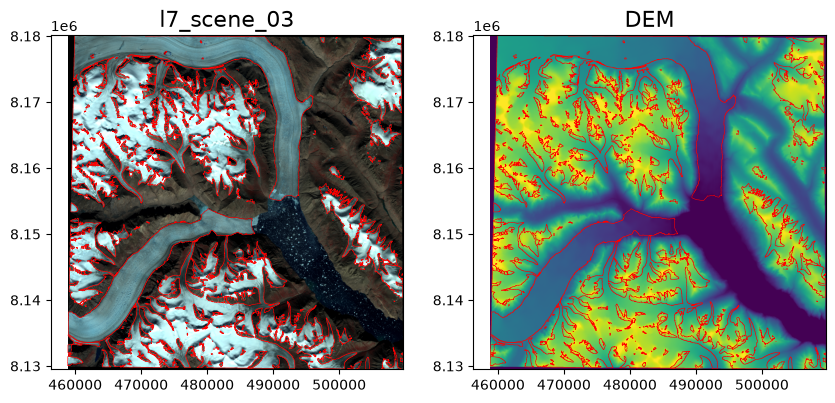

In [16]:
  ## data paths
dset = list(zip(paths_scene, paths_dem, paths_truth_vec))
for i, (path_scene, path_dem, path_truth) in enumerate(dset[15:17]):
        scene_name = path_scene.split('/')[-1].split('.')[0]
        truth_gdf = gpd.read_file(path_truth)
        ## plot
        fig, ax = plt.subplots(1,2, figsize=(10,5))
        ## scene
        scene_rio = rio.open(path_scene)
        extent_rsimg = [scene_rio.bounds[0], scene_rio.bounds[2],
                        scene_rio.bounds[1], scene_rio.bounds[3]]
        imgShow(img=scene_rio.read([2,3,4]).transpose(1,2,0),
                extent=extent_rsimg, 
                clip_percent=5,
                ax=ax[0])
        truth_gdf.plot(ax=ax[0], 
                facecolor='none', 
                edgecolor='red', linewidth=0.4)
        ax[0].set_title(scene_name, fontsize=16)
        ## dem
        dem_rio = rio.open(path_dem)
        extent_dem = [dem_rio.bounds[0], dem_rio.bounds[2],
                      dem_rio.bounds[1], dem_rio.bounds[3]]
        imgShow(img=dem_rio.read()[0],
                        extent=extent_dem, 
                        clip_percent=1,
                        ax=ax[1])
        truth_gdf.plot(ax=ax[1], 
                facecolor='none',
                edgecolor='red', linewidth=0.4)
        ax[1].set_title('DEM', fontsize=16)
        plt.show()
        break


#### 2 statistics of the dataset   
2.1 check glacier and non-glacier pixel samples.

In [23]:
truth_arr = {'l5': [], 'l7': [], 'l8': [],'l9': [], 's2': []}
for path_truth in paths_truth:
  sat = path_truth.split('/')[-1].split('_')[0]
  truth_arr[sat].append(rio.open(path_truth).read().flatten())
truth_arr = {key: np.concatenate(truth_arr[key]) for key in truth_arr} 


In [24]:
## statistics: (1) total pixels per satellite; 
## (2) glacier pixels vs. non-glacier pixels. 
total_pixel_sat = {key: truth_arr[key].shape[0] for key in truth_arr}
glacier_pixel_sat = {key: np.sum(truth_arr[key] == 1) for key in truth_arr}
non_glacier_pixel_sat = {key: np.sum(truth_arr[key] == 0) for key in truth_arr}
glacier_pixel_total = np.sum(list(glacier_pixel_sat.values()))
non_glacier_pixel_total = np.sum(list(non_glacier_pixel_sat.values()))
print('Total glacier pixels:', glacier_pixel_total)
print('Total pixels per satellite:', total_pixel_sat)
print('Glacier pixels per satellite:', glacier_pixel_sat)
print('Non-glacier pixels per satellite:', non_glacier_pixel_sat)
print('Total non-glacier pixels:', non_glacier_pixel_total) 


Total glacier pixels: 99737839
Total pixels per satellite: {'l5': 38690504, 'l7': 39345489, 'l8': 40751989, 'l9': 38750046, 's2': 162688784}
Glacier pixels per satellite: {'l5': np.int64(8985805), 'l7': np.int64(8243595), 'l8': np.int64(7777412), 'l9': np.int64(9643526), 's2': np.int64(65087501)}
Non-glacier pixels per satellite: {'l5': np.int64(29704699), 'l7': np.int64(31101894), 'l8': np.int64(32974577), 'l9': np.int64(29106520), 's2': np.int64(97601283)}
Total non-glacier pixels: 220488973


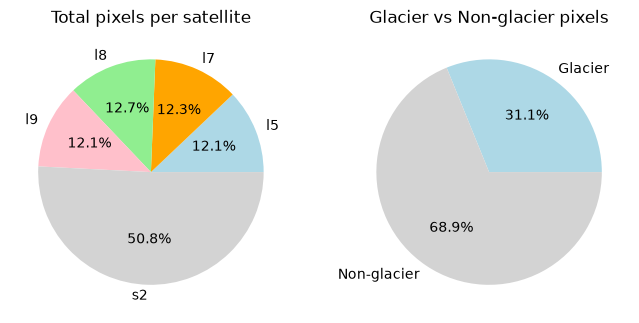

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
colors_sat = ['lightblue', 'orange', 'lightgreen', 'pink', 'lightgrey']
colors_gla_nongla = ['lightblue', 'lightgrey']
ax[0].pie(list(total_pixel_sat.values()), 
        labels=list(total_pixel_sat.keys()),
        autopct='%1.1f%%', 
        colors=colors_sat)
ax[0].set_title('Total pixels per satellite') 
ax[1].pie([glacier_pixel_total, non_glacier_pixel_total],
        labels=['Glacier', 'Non-glacier'],
        autopct='%1.1f%%',
        colors=colors_gla_nongla,
        startangle=0)
ax[1].set_title('Glacier vs Non-glacier pixels')
# fig.savefig('figs/dset_stats.png', dpi=300) 


2.2 check the distribution of the dataset


In [27]:
dset_gdf = gpd.read_file('data/dset/dset.gpkg')


In [28]:
sat_colors = {'l5': 'red', 
              'l7': 'green', 
              'l8': 'blue', 
              'l9': 'orange', 
              's2': 'purple'}
sat_names = {'l5': 'Landsat 5', 
              'l7': 'Landsat 7', 
              'l8': 'Landsat 8', 
              'l9': 'Landsat 9', 
              's2': 'Sentinel 2'}

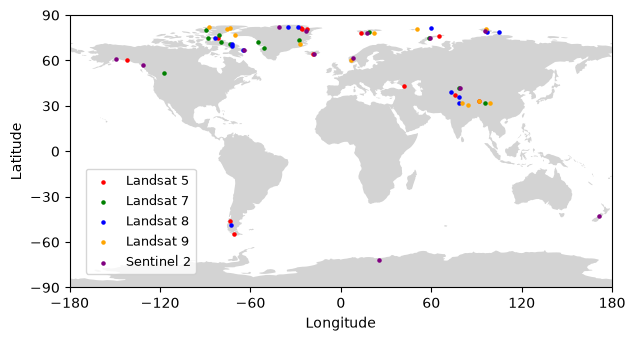

In [29]:
fig, ax = plt.subplots(figsize=(7, 5), 
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set_extent([-180, 180, -90, 90])
for sat, color in sat_colors.items():
    dset_gdf[dset_gdf.satellite == sat].plot(
                ax=ax, color=color, markersize=5, label=sat_names[sat])

ax.legend(loc=(0.03,0.05), fontsize=9)
ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.tick_params(labelsize=10)
## fig.savefig('figs/dset_distribution.png')
